In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [ ]:
train_df = pd.read_csv("mitbih_train.csv", header=None)

test_df = pd.read_csv("mitbih_test.csv", header=None)

print(train_df.shape)

train_df.head()

(87554, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train = train_df.iloc[:, :-1].values

y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values

y_test = test_df.iloc[:, -1].values

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

In [ ]:
gru_model = Sequential()

gru_model.add(
    GRU(
        64,
        input_shape=(187, 1)
    )
)

gru_model.add(
    Dropout(0.2)
)

gru_model.add(
    Dense(
        32,
        activation='relu'
    )
)

gru_model.add(
    Dense(
        5,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109 (59.02 KB)

 Trainable params: 15,109 (59.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 204s 292ms/step - accuracy: 0.8273 - loss: 0.6760 - val_accuracy: 0.8278 - val_loss: 0.6415
Epoch 2/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 200s 290ms/step - accuracy: 0.8278 - loss: 0.6316 - val_accuracy: 0.8286 - val_loss: 0.6216
Epoch 3/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 209s 305ms/step - accuracy: 0.8772 - loss: 0.4258 - val_accuracy: 0.9101 - val_loss: 0.3308
Epoch 4/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 202s 295ms/step - accuracy: 0.9190 - loss: 0.2936 - val_accuracy: 0.9262 - val_loss: 0.2800
Epoch 5/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 209s 304ms/step - accuracy: 0.9307 - loss: 0.2494 - val_accuracy: 0.9235 - val_loss: 0.2654
Epoch 6/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 201s 293ms/step - accuracy: 0.9375 - loss: 0.2247 - val_accuracy: 0.9458 - val_loss: 0.1987
Epoch 7/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 201s 294ms/step - accuracy: 0.9476 - loss: 0.1905 - val_accuracy: 0.9510 - val_loss: 0.1818
Epoch 8/10
685/685 ━━━━━━━━━━━━━━━━━━━━ 208s 303ms/step - accuracy: 0.9543 -

In [ ]:
loss, accuracy = gru_model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

685/685 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9629 - loss: 0.1407
Test Accuracy: 0.9628631472587585


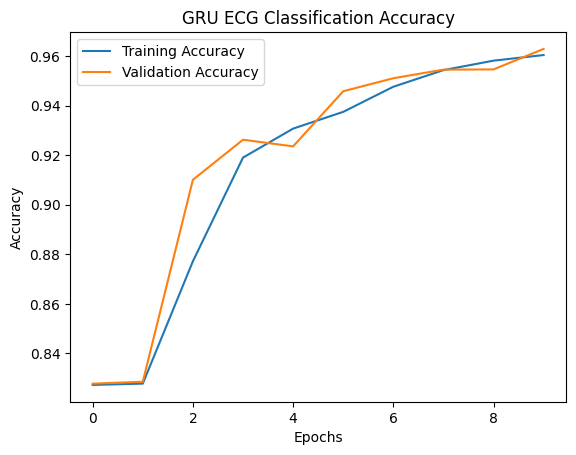

In [ ]:
plt.plot(
    gru_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    gru_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.title("GRU ECG Classification Accuracy")

plt.show()